In [7]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import zipfile
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.nn.modules.conv import Conv2d

In [8]:
model_path = 'Flowers.zip'


In [11]:
with zipfile.ZipFile("/content/Flowers.zip", 'r') as zip_fer:
  zip_fer.extractall('.')

In [66]:
transforms_data = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [67]:
train_data = datasets.ImageFolder('/content/Flowers/train', transform=transforms_data)
test_data = datasets.ImageFolder('/content/Flowers/test', transform=transforms_data)

In [68]:
data_train = train_data.classes

In [69]:
len(data_train)

5

In [70]:
classess = data_train

In [71]:
train = DataLoader(train_data, batch_size=50, shuffle=True)
test = DataLoader(test_data, batch_size=50)

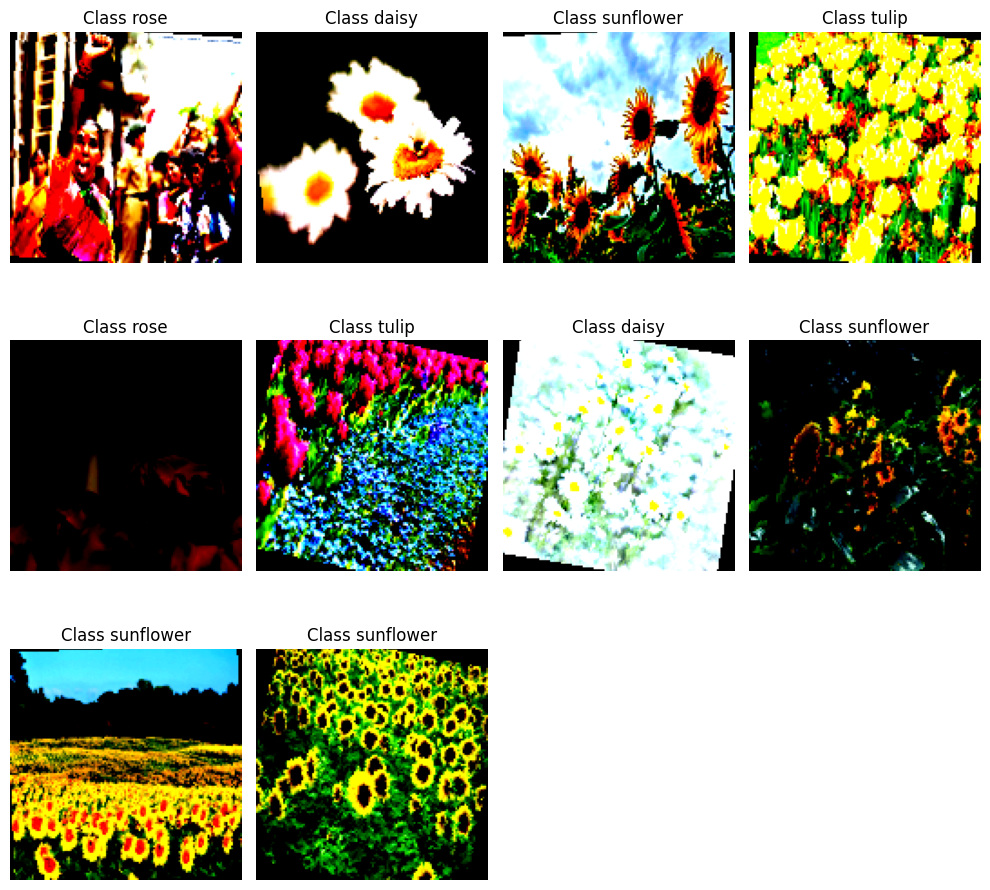

In [72]:
image, label = next(iter(train))
plt.figure(figsize=(10, 10))
for i in range(10):
  plt.subplot(3, 4, i+1)
  plt.imshow(image[i].permute(1, 2, 0))
  plt.title(f'Class {classess[label[i]]}')
  plt.axis('off')
  plt.tight_layout()
plt.show()

In [73]:
class ChechImage(nn.Module):
  def __init__(self):
    super().__init__()
    self.first = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2), #128

        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True), #64
        nn.MaxPool2d(2),

        nn.Conv2d(256, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True), #32
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2), #8

        nn.Conv2d(256, 512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True), #4
        nn.MaxPool2d(2)

    )
    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512 * 4 * 4, 128),
        nn.ReLU(),
        nn.Linear(128, 5)
    )
  def forward(self, x):
    x = self.first(x)
    x = self.second(x)
    return x


In [92]:
class CheckImage3(nn.Module):
  def __init__(self):
    super().__init__()
    self.first = nn.Sequential(
        nn.Conv2d(3, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(256, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512 * 16 * 16, 512),
        nn.ReLU(),
        nn.Linear(512, 5)
    )
  def forward(self, x):
    x = self.first(x)
    x = self.second(x)
    return x

In [91]:
class ChechImage1(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.second = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 5)
        )

    def forward(self, x):
        x = self.first(x)
        x = self.second(x)
        return x

In [102]:
class ChechImage4(nn.Module):
   def __init__(self):
     super().__init__()
     self.first = nn.Sequential(
          nn.Conv2d(3, 128, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Conv2d(128, 256, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Conv2d(256, 512, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2))

     self.second = nn.Sequential(
          nn.Flatten(),
          nn.Linear(512 * 16 * 16, 512),
          nn.ReLU(), nn.Linear(512, 5) )
   def forward(self, x):
     x = self.first(x)
     x = self.second(x)
     return x

In [103]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [105]:
models1 = ChechImage().to(device)
models2 = ChechImage1().to(device)
models3 = CheckImage3().to(device)
models4 = ChechImage4().to(device)

In [106]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(models1.parameters(), lr=0.001)
loss_fn_1 = nn.CrossEntropyLoss()
optimizer = optim.Adam(models2.parameters(), lr=0.003)
loss_fn_2 = nn.CrossEntropyLoss()
optimizer = optim.Adam(models3.parameters(), lr=0.001)
loss_fn_3 = nn.CrossEntropyLoss()
optimizer = optim.Adam(models4.parameters(), lr=0.001)


In [55]:
for epoch in range(5):
  models1.train()
  total_loss = 0
  for x_bath, y_bath in train:
    x_bath, y_bath = x_bath.to(device), y_bath.to(device)

    y_pred = models1(x_bath)
    l = loss_fn(y_pred, y_bath)

    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    total_loss += l.item()

  print(f'Epoch {epoch+1}, Loss: {round(total_loss, 2)}')

Epoch 1, Loss: 89.6
Epoch 2, Loss: 89.82
Epoch 3, Loss: 89.75
Epoch 4, Loss: 89.71
Epoch 5, Loss: 89.87


In [78]:
for epoch in range(30):
  models2.train()
  total_loss = 0
  for x_bath, y_bath in train:
    x_bath, y_bath = x_bath.to(device), y_bath.to(device)

    y_pred = models2(x_bath)
    l = loss_fn(y_pred, y_bath)

    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    total_loss += l.item()

  print(f'Epoch {epoch+1}, Loss: {round(total_loss, 2)}')

Epoch 1, Loss: 837.93
Epoch 2, Loss: 85.89
Epoch 3, Loss: 83.92
Epoch 4, Loss: 80.16
Epoch 5, Loss: 76.73
Epoch 6, Loss: 77.26
Epoch 7, Loss: 76.16
Epoch 8, Loss: 76.71
Epoch 9, Loss: 74.55
Epoch 10, Loss: 74.8
Epoch 11, Loss: 73.56
Epoch 12, Loss: 75.12
Epoch 13, Loss: 74.19
Epoch 14, Loss: 74.18
Epoch 15, Loss: 74.67
Epoch 16, Loss: 77.28
Epoch 17, Loss: 75.4
Epoch 18, Loss: 74.32
Epoch 19, Loss: 76.28
Epoch 20, Loss: 75.27
Epoch 21, Loss: 73.16
Epoch 22, Loss: 72.54
Epoch 23, Loss: 73.1
Epoch 24, Loss: 70.63
Epoch 25, Loss: 70.93
Epoch 26, Loss: 73.41
Epoch 27, Loss: 74.1
Epoch 28, Loss: 72.73
Epoch 29, Loss: 71.44
Epoch 30, Loss: 71.83


In [97]:
for epoch in range(30):
  models3.train()
  total_loss = 0
  for x_bath, y_bath in train:
    x_bath, y_bath = x_bath.to(device), y_bath.to(device)

    y_pred = models3(x_bath)
    loss_val = loss_fn_2(y_pred, y_bath)

    optimizer.zero_grad()
    loss_val.backward()
    optimizer.step()
    total_loss += loss_val.item()

  print(f'Epoch {epoch+1}, Loss: {round(total_loss, 2)}')

Epoch 1, Loss: 117.33
Epoch 2, Loss: 66.54
Epoch 3, Loss: 59.44
Epoch 4, Loss: 53.4
Epoch 5, Loss: 49.56
Epoch 6, Loss: 46.72
Epoch 7, Loss: 44.84
Epoch 8, Loss: 43.22
Epoch 9, Loss: 41.84
Epoch 10, Loss: 39.01
Epoch 11, Loss: 36.26
Epoch 12, Loss: 34.45
Epoch 13, Loss: 32.45
Epoch 14, Loss: 31.54
Epoch 15, Loss: 29.38
Epoch 16, Loss: 27.75
Epoch 17, Loss: 24.21
Epoch 18, Loss: 23.63
Epoch 19, Loss: 22.32
Epoch 20, Loss: 19.24
Epoch 21, Loss: 18.08
Epoch 22, Loss: 17.5
Epoch 23, Loss: 15.3
Epoch 24, Loss: 13.03
Epoch 25, Loss: 13.03
Epoch 26, Loss: 14.38
Epoch 27, Loss: 14.46
Epoch 28, Loss: 10.11
Epoch 29, Loss: 10.9
Epoch 30, Loss: 10.12


In [109]:
for epoch in range(2):
  models4.train()
  total_loss = 0
  for x_bath, y_bath in train:
    x_bath, y_bath = x_bath.to(device), y_bath.to(device)

    y_pred = models4(x_bath)
    loss_val = loss_fn_3(y_pred, y_bath)

    optimizer.zero_grad()
    loss_val.backward()
    optimizer.step()
    total_loss += loss_val.item()

  print(f'Epoch {epoch+1}, Loss: {round(total_loss, 2)}')

Epoch 1, Loss: 14.42
Epoch 2, Loss: 12.77
Epoch 3, Loss: 11.61
Epoch 4, Loss: 10.44
Epoch 5, Loss: 8.77
Epoch 6, Loss: 9.48
Epoch 7, Loss: 8.35


In [98]:
model_eval = models1.eval()
mod = models2.eval()
model_eval_3 = models3.eval()
model_eval_4 = models4.eval()

In [99]:
models3.eval()
correct = 0
total = 0
with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = models2(x_batch)
    pred = torch.max(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (pred.indices == y_batch).sum().item()
accuracy = 100 * correct/total
print(f'Accuracy: {accuracy} %')

Accuracy: 20.222634508348794 %


In [79]:
models2.eval()
correct = 0
total = 0
with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = models2(x_batch)
    pred = torch.max(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (pred.indices == y_batch).sum().item()
accuracy = 100 * correct/total
print(f'Accuracy: {accuracy} %')

Accuracy: 47.680890538033395 %


In [57]:
models1.eval()
correct = 0
total = 0
with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = models1(x_batch)
    pred = torch.max(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (pred.indices == y_batch).sum().item()
accuracy = 100 * correct/total
print(f'Accuracy: {accuracy} %')

Accuracy: 18.923933209647494 %


In [110]:
models4.eval()
correct = 0
total = 0
with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = models4(x_batch)
    pred = torch.max(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (pred.indices == y_batch).sum().item()
accuracy = 100 * correct/total
print(f'Accuracy: {accuracy} %')

Accuracy: 69.75881261595548 %


In [111]:
torch.save(models4.state_dict(), 'model_flowers.pth')
torch.save(models2.state_dict(), 'model2_flowers.pth')